<a href="https://colab.research.google.com/github/Jirtus-sanasam/MLP-Diabetes/blob/main/FeatureEngineering1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/diabetes_data2.csv')

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
cols_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
cols_valid_zero = ['Pregnancies', 'DiabetesPedigreeFunction']

In [ ]:
df[cols_invalid_zero] = df[cols_invalid_zero].replace(0, np.nan)

In [ ]:
# Check missing values after replacement
print(df[cols_invalid_zero].isnull().sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Age                0
dtype: int64


In [ ]:
for col in cols_invalid_zero:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_3640/3491598505.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
  # Confirm no nulls remain
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
print(df[cols_invalid_zero].describe())

          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  768.000000     768.000000     768.000000  768.000000  768.000000
mean   121.686763      72.405184      29.153420  155.548223   32.457464
std     30.435949      12.096346       8.790942   85.021108    6.875151
min     44.000000      24.000000       7.000000   14.000000   18.200000
25%     99.750000      64.000000      25.000000  121.500000   27.500000
50%    117.000000      72.202592      29.153420  155.548223   32.400000
75%    140.250000      80.000000      32.000000  155.548223   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


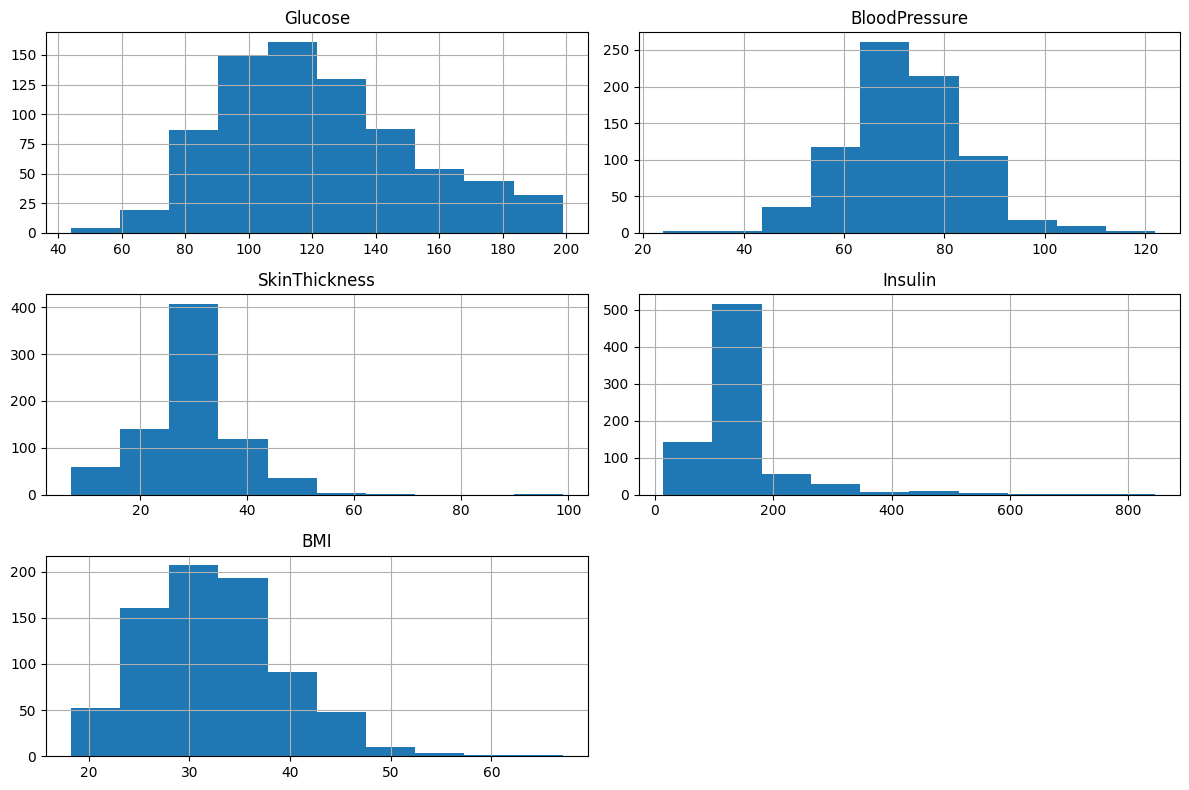

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of each column
df[cols_invalid_zero].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

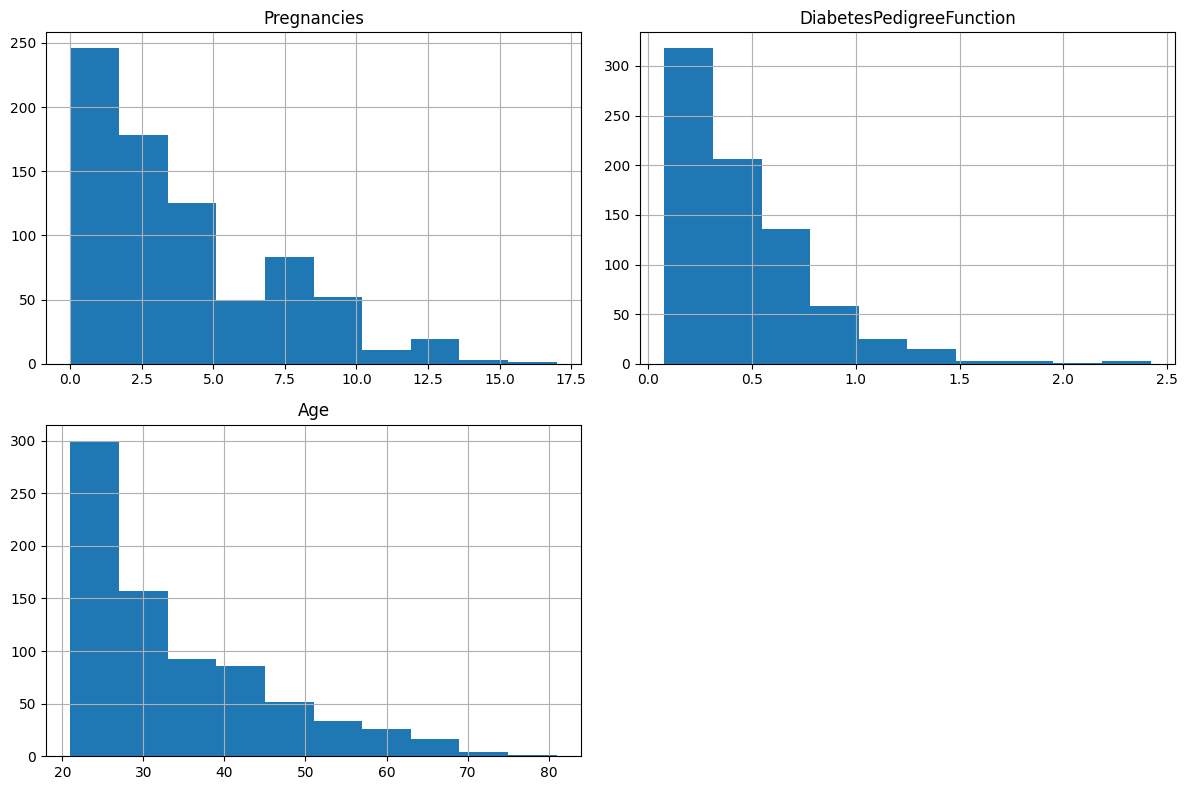

In [ ]:
# Distribution of each column
cols_othr = ['Pregnancies', 'DiabetesPedigreeFunction', 'Age']
df[cols_othr].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

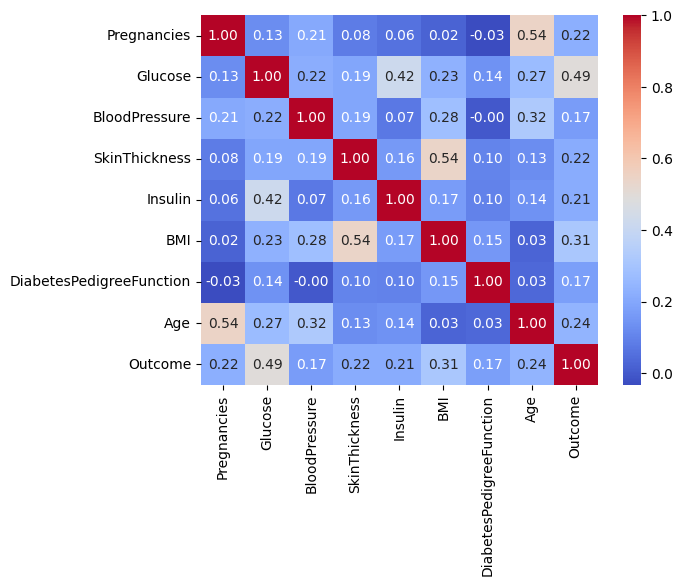

In [ ]:
# Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Outcome
0    500
1    268
Name: count, dtype: int64


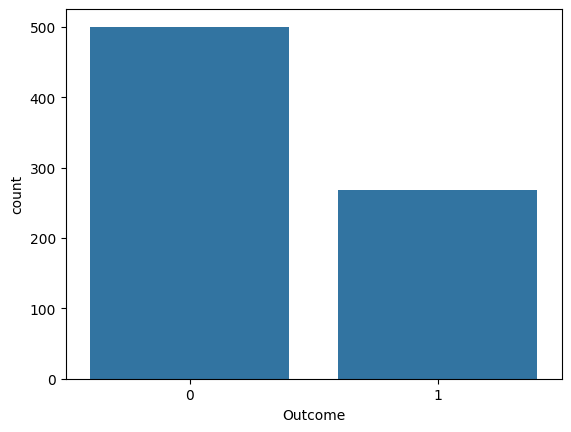

In [ ]:
# Check class balance (assuming 'Outcome' is the target)
print(df['Outcome'].value_counts())
sns.countplot(x='Outcome', data=df)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

In [ ]:
print(X.head().T)

                                   0           1           2       3        4
Pregnancies                 6.000000    1.000000    8.000000   1.000    0.000
Glucose                   148.000000   85.000000  183.000000  89.000  137.000
BloodPressure              72.000000   66.000000   64.000000  66.000   40.000
SkinThickness              35.000000   29.000000   29.153420  23.000   35.000
Insulin                   155.548223  155.548223  155.548223  94.000  168.000
BMI                        33.600000   26.600000   23.300000  28.100   43.100
DiabetesPedigreeFunction    0.627000    0.351000    0.672000   0.167    2.288
Age                        50.000000   31.000000   32.000000  21.000   33.000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
print("After SMOTE: ", dict(pd.Series(y_train_sm).value_counts()))

Before SMOTE: {0: np.int64(400), 1: np.int64(214)}
After SMOTE:  {0: np.int64(400), 1: np.int64(400)}
